Tooth Appendix Plot: Panel (a) on linear x-axis scale

In [1]:
import matplotlib as mpl

mpl.rcParams.update({

    # -------- Lines --------
    "lines.linewidth": 2,
    "lines.markersize": 4.5,

    # -------- Axes labels --------
    "axes.labelsize": 14,
    "axes.titlesize": 14,

    # -------- Tick labels --------
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,

    # -------- Legend --------
    "legend.fontsize": 11,

    # -------- Grid --------
    "grid.alpha": 0.25,

})

In [2]:
def plot_A_linear(ax):
    """
    Tooth — Plot A (linear x-axis main panel, inset with log-frequency y-axis)
    """

    import numpy as np
    import pandas as pd
    from pathlib import Path
    from mpl_toolkits.axes_grid1.inset_locator import inset_axes

    # ===================================
    # Configuration
    # ===================================
    base_dir = Path(
        '/Users/sam/Documents/Oxford/Physics/sloppiness/'
        'circadian/mut_project_updates/figures/tooth model/'
        'plot_a/plot_a_files'
    )

    cusp_filter = None
    n_bins = 30

    # ===================================
    # Helper functions
    # ===================================

    def get_file_paths(base_dir):
        rand_path = base_dir / "Rand" / "RandOPCandCusp.txt"
        mut0_path = base_dir / "0mut" / "0mut_cusp_and_opc_9000.txt"

        if not rand_path.exists():
            raise FileNotFoundError(rand_path)
        if not mut0_path.exists():
            raise FileNotFoundError(mut0_path)

        return rand_path, mut0_path

    def read_file(path):
        df = pd.read_csv(path, sep=r'\s+|\t', engine='python')
        df.columns = df.columns.str.strip()

        for col in ['ID', 'Cusps', 'OPC']:
            df[col] = pd.to_numeric(df[col], errors='coerce')

        df = df.dropna()
        return df

    def process_dataset(df, cusp_filter):
        if cusp_filter is not None:
            df = df[df['Cusps'] == cusp_filter]

        opc = df['OPC'].values
        return opc[opc > 0]

    # ===================================
    # Load data
    # ===================================

    rand_path, mut0_path = get_file_paths(base_dir)

    df_rand = read_file(rand_path)
    df_0_mut = read_file(mut0_path)

    rand_raw = process_dataset(df_rand, cusp_filter)
    zero_raw = process_dataset(df_0_mut, cusp_filter)

    # ===================================
    # Linear bins
    # ===================================

    all_data = np.concatenate([rand_raw, zero_raw])
    min_val = all_data.min()
    max_val = all_data.max()

    bins = np.linspace(min_val, max_val, n_bins)

    rand_counts, bin_edges = np.histogram(rand_raw, bins=bins)
    zero_counts, _ = np.histogram(zero_raw, bins=bins)

    rand_counts = rand_counts / rand_counts.sum()
    zero_counts = zero_counts / zero_counts.sum()

    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    # ===================================
    # Adaptive epsilon for inset (avoid log(0))
    # ===================================

    nonzeros = np.concatenate([
        rand_counts[rand_counts > 0],
        zero_counts[zero_counts > 0]
    ])

    eps = np.min(nonzeros) * 0.1 if nonzeros.size else 1e-12

    rand_safe = np.clip(rand_counts, eps, None)
    zero_safe = np.clip(zero_counts, eps, None)

    # ===================================
    # Main plot (linear x-axis)
    # ===================================

    ax.plot(bin_centers, rand_counts,
            marker='o',
            color="orange",
            label="G-dist")

    ax.fill_between(bin_centers, rand_counts, 0,
                    color="orange", alpha=0.18)

    ax.plot(bin_centers, zero_counts,
            marker='o',
            color="blue",
            label="P-dist")

    ax.fill_between(bin_centers, zero_counts, 0,
                    color="blue", alpha=0.15)

    ax.set_xlabel("Complexity (OPCR)")
    ax.set_ylabel("Relative Frequency")

    ax.legend(frameon=False, loc="upper center")
    ax.grid(False)
    ax.set_axisbelow(True)

    # ===================================
    # Inset (log-frequency on y-axis only)
    # ===================================

    ax_inset = inset_axes(ax, width="25%", height="25%", loc="upper right")

    ax_inset.plot(bin_centers, rand_safe, color="orange")
    ax_inset.plot(bin_centers, zero_safe, color="blue")

    ax_inset.set_yscale("log")  # <-- log frequency only

    ax_inset.set_xlabel("Complexity", fontsize=8)
    ax_inset.set_ylabel("Log Frequency", fontsize=8)
    ax_inset.tick_params(labelsize=7)

    return ax

/var/folders/yr/bzwkxpcj34x73kc2trlk0h2m0000gn/T/ipykernel_99647/1152865280.py:5: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


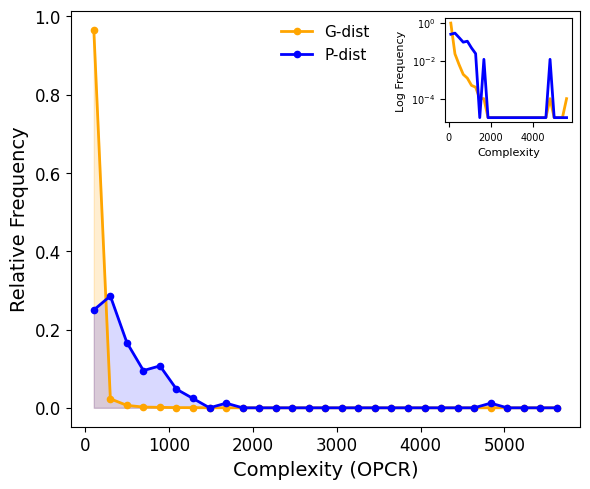

In [3]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6,5))
plot_A_linear(ax)
fig.tight_layout()
plt.show()